# Decision Tree Regression
### Definition
Decision tree algorithms use a tree of inequalities to estimate data target values by maximizing the amount of information gain with the inequality among the features.

### Algorithm
The decision tree algorithm used for regression is a part of CART (classification and regression trees). 
1. First, we select the split that minimizes the prediction error (by MSE) within the child nodes.
2. Then, create child nodes based on the split.
3. Repeat for all child nodes until either a max depth is reached or the MSE is sufficiently small (so prediction is good)

## Imports

In [67]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error
from mlxtend.plotting import plot_decision_regions

import struct

sns.set_theme()

## Data Preprocessing
We will load in the AutoMPG data that we created in the preprocessing step:

In [68]:
data_dir = "/home/patrick/Projects/DataScienceAndMachineLearning/Data/AutoMPG-Dataset"
train_X = np.load(f"{data_dir}/train_X.npy")
train_y = np.load(f"{data_dir}/train_y.npy")
test_X = np.load(f"{data_dir}/test_X.npy")
test_y = np.load(f"{data_dir}/test_y.npy")
train_X

array([[ 1.49630792,  1.08923273,  0.66835485, ...,  0.77258661,
        -0.46138749, -0.49701778],
       [ 1.49630792,  1.50162428,  1.58460471, ...,  0.77258661,
        -0.46138749, -0.49701778],
       [ 1.49630792,  1.19472824,  1.1919262 , ...,  0.77258661,
        -0.46138749, -0.49701778],
       ...,
       [-0.85524411, -0.69460048,  0.27567634, ..., -1.29110112,
         2.16192996, -0.49701778],
       [ 0.3205319 , -0.29179943,  0.74689055, ..., -1.29110112,
         2.16192996, -0.49701778],
       [-0.85524411, -1.00149651, -0.87618062, ..., -1.29110112,
         2.16192996, -0.49701778]], shape=(279, 8))

## Data Analysis

First, fit with an initial depth:

In [69]:
regressor = DecisionTreeRegressor(max_depth=2)
col = 2
regressor.fit(train_X[:, 2:3], train_y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

Now, plot the decision tree with plot_tree:

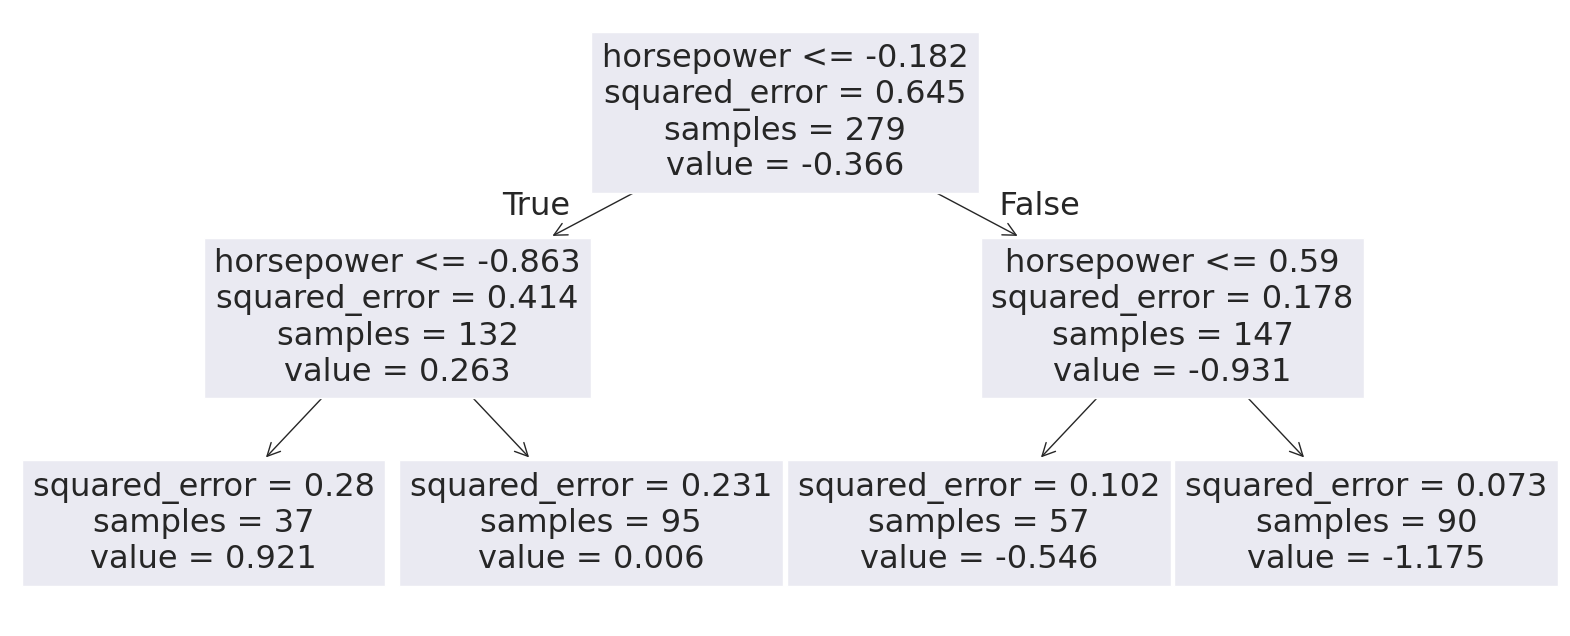

In [70]:
plt.figure(figsize=(20, 8))
feature_names = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "is_USA", "is_Europe", "is_Japan"]
plot_tree(regressor, feature_names=[feature_names[3]])
plt.show()

Finally, plot the decision tree against the data:

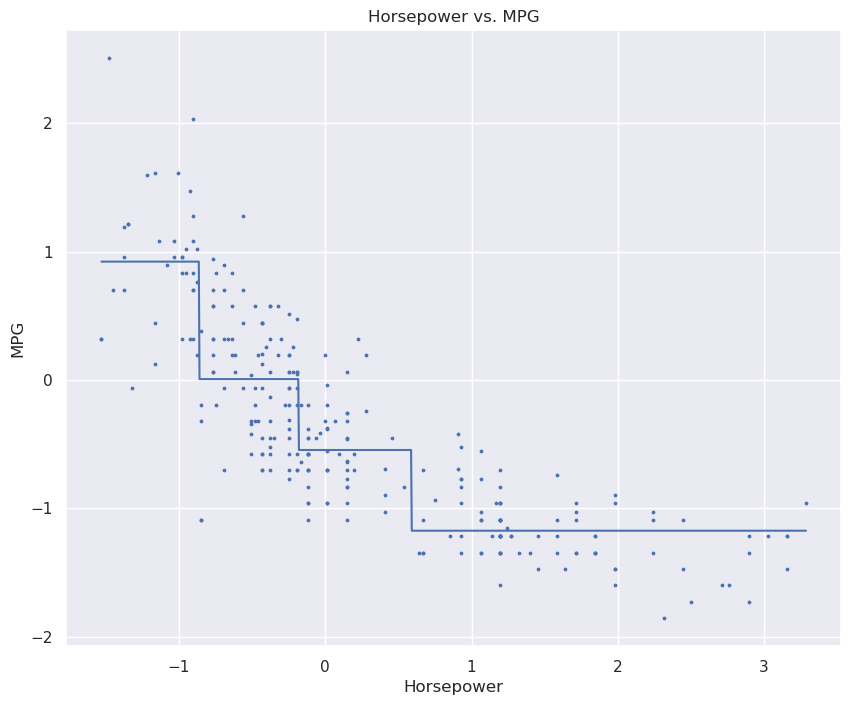

In [71]:
plt.figure(figsize = (10, 8))

t = np.linspace(min(train_X[:, 2]), max(train_X[:, 2]), 1000)[:, np.newaxis]
t_y = regressor.predict(t)

plt.plot(t, t_y)
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title(f"Horsepower vs. MPG")
plt.scatter(train_X[:, 2], train_y[:], s = 3)


Show MSE:

In [72]:
preds = regressor.predict(test_X[:, 2:3])
mse = mean_squared_error(test_y, preds)
mse

0.9360264864170526

## More Data Analysis

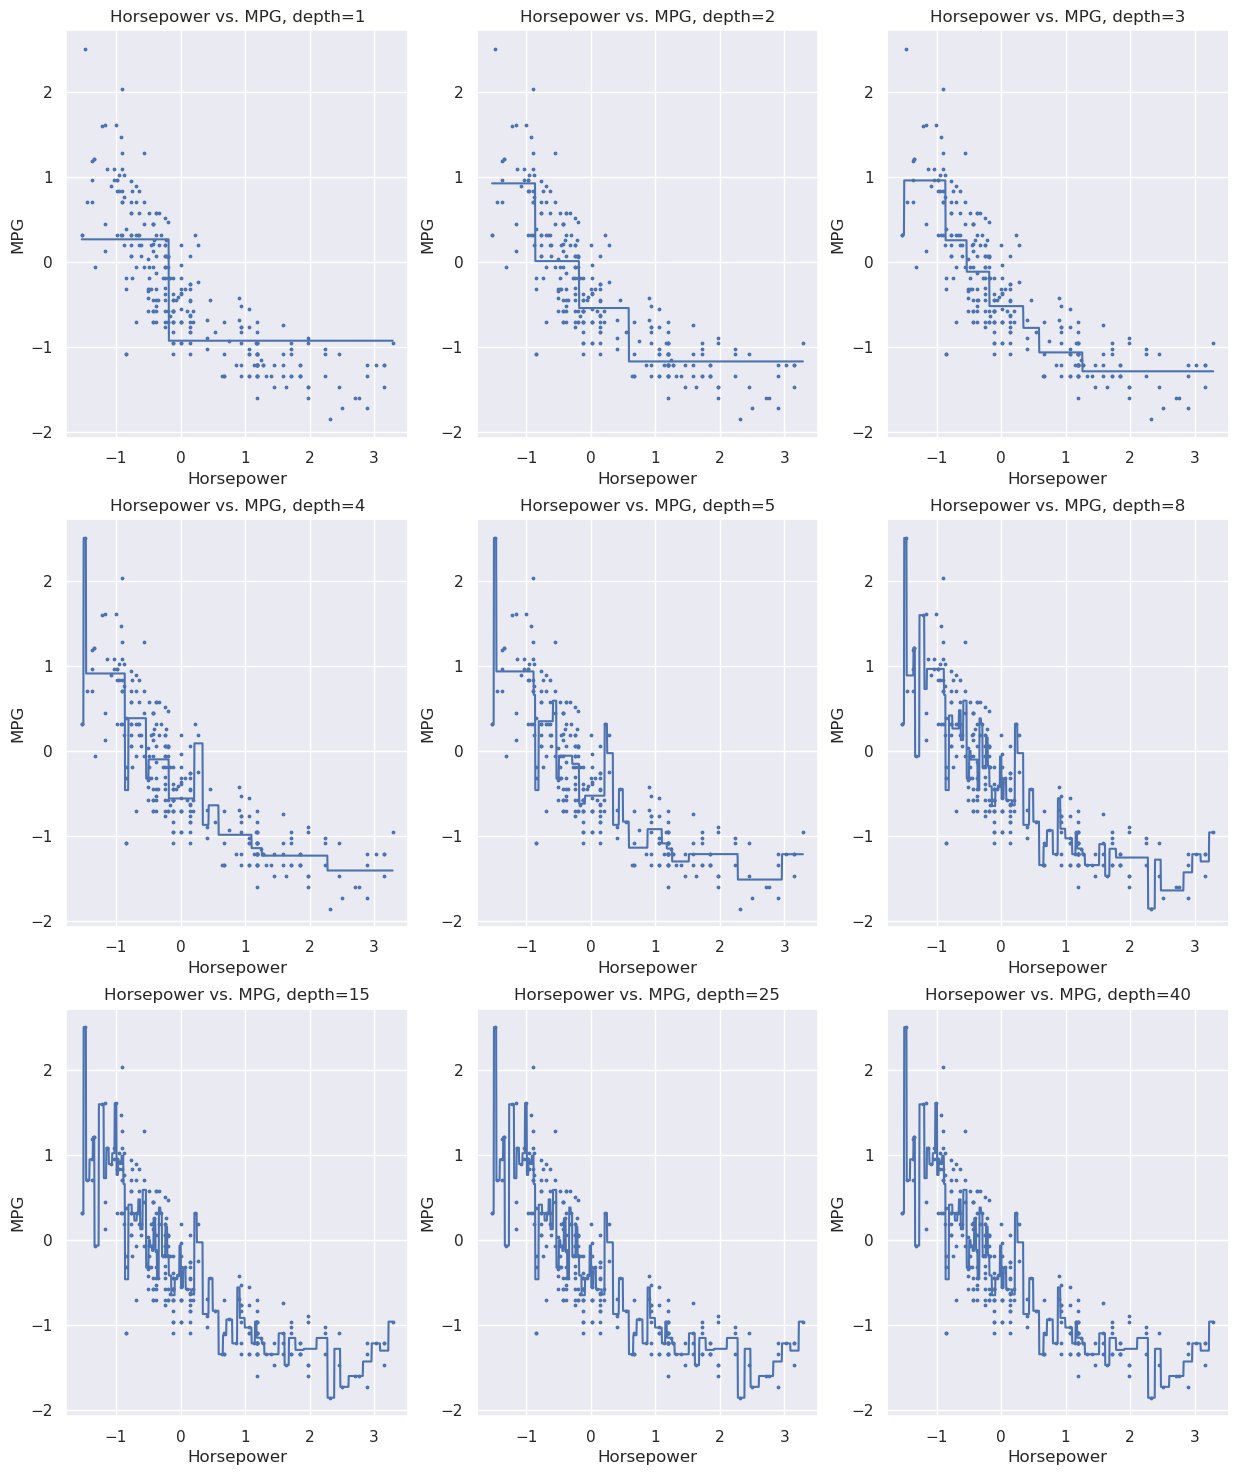

In [76]:
fig, axs = plt.subplots(3, 3, figsize = (15, 18))
t = np.linspace(min(train_X[:, 2]), max(train_X[:, 2]), 1000)[:, np.newaxis]
mse_vals = []
depths = [1, 2, 3, 4, 5, 8, 15, 25, 40]

for (k, depth) in enumerate(depths):
    regressor = DecisionTreeRegressor(max_depth=depth)
    col = 2
    regressor.fit(train_X[:, 2:3], train_y)

    t_y = regressor.predict(t)

    i, j = k // 3, k % 3

    axs[i, j].plot(t, t_y)
    axs[i, j].set_xlabel("Horsepower")
    axs[i, j].set_ylabel("MPG")
    axs[i, j].set_title(f"Horsepower vs. MPG, depth={depth}")
    axs[i, j].scatter(train_X[:, 2], train_y[:], s = 3)

    preds = regressor.predict(test_X[:, 2:3])
    mse = mean_squared_error(test_y, preds)
    mse_vals.append(mse)
plt.show()

In [78]:
for (j, mse) in enumerate(mse_vals):
    print(f"Depth {depths[j]:2d}: MSE {mse: 1.3f}")

Depth  1: MSE  1.341
Depth  2: MSE  0.936
Depth  3: MSE  0.885
Depth  4: MSE  0.851
Depth  5: MSE  0.849
Depth  8: MSE  0.784
Depth 15: MSE  0.802
Depth 25: MSE  0.802
Depth 40: MSE  0.802


We can see that, according to MSE for testing data, the depth 8 tree is the best prediction. However, the plots show highly oscillatory decision trees, showing that the decision tree regression might not model the data as well as it can be modeled.

## Full-dimension Data Analysis

In [79]:
mse_vals = []
depths = [1, 2, 3, 4, 5, 8, 15, 25, 40]

for (k, depth) in enumerate(depths):
    regressor = DecisionTreeRegressor(max_depth=depth)
    col = 2
    regressor.fit(train_X, train_y)

    preds = regressor.predict(test_X)
    mse = mean_squared_error(test_y, preds)
    mse_vals.append(mse)

In [80]:
for (j, mse) in enumerate(mse_vals):
    print(f"Depth {depths[j]:2d}: MSE {mse: 1.3f}")

Depth  1: MSE  1.212
Depth  2: MSE  1.068
Depth  3: MSE  1.003
Depth  4: MSE  1.015
Depth  5: MSE  1.045
Depth  8: MSE  1.002
Depth 15: MSE  0.988
Depth 25: MSE  0.968
Depth 40: MSE  1.013


Here, we can see that, looking at the full-dimension data, the minimum MSE is at a depth of 25.